Environment Definition

In [36]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install tqdm
%pip install seaborn


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns

In [38]:
class Bandit:
    def __init__(self, n_arms):
        self.n_arms = n_arms
        
    def select_arm(self, context=None):
        raise NotImplementedError
        
    def update(self, arm, reward, context=None):
        raise NotImplementedError

In [39]:
class UCB(Bandit):
    def __init__(self, n_arms, delta):
        super().__init__(n_arms)
        self.delta = delta
        self.pulls = np.zeros(n_arms)
        self.rewards = np.zeros(n_arms)
        self.t = 0
        
    def select_arm(self, context=None):
        self.t += 1
        
        if np.any(self.pulls == 0):
            return np.argmin(self.pulls)
            
        empirical_mean = self.rewards / self.pulls
        confidence_bound = np.sqrt((2 * np.log(1 / self.delta)) / self.pulls)
        
        ucb_values = empirical_mean + confidence_bound
        return np.argmax(ucb_values)
        
    def update(self, arm, reward, context=None):
        self.pulls[arm] += 1
        self.rewards[arm] += reward

In [40]:
class LinUCB(Bandit):
    def __init__(self, n_arms, d, lambda_reg=1.0, alpha=1.0):
        super().__init__(n_arms)
        self.d = d
        self.lambda_reg = lambda_reg
        self.alpha = alpha        

        self.V = np.array([lambda_reg * np.eye(d) for _ in range(n_arms)])
        self.V_inv = np.array([np.linalg.inv(self.V[i]) for i in range(n_arms)])
        self.B = np.zeros((n_arms, d))
        
    def select_arm(self, context):
        ucb_values = np.zeros(self.n_arms)
        
        for a in range(self.n_arms):
            theta_hat = self.V_inv[a] @ self.B[a]
            
            variance = context.T @ self.V_inv[a] @ context
            
            ucb_values[a] = np.dot(context, theta_hat) + self.alpha * np.sqrt(variance)
            
        return np.argmax(ucb_values)
        
    def update(self, arm, reward, context):
        self.V[arm] += np.outer(context, context)
        self.B[arm] += reward * context
        self.V_inv[arm] = np.linalg.inv(self.V[arm])

In [41]:
def run_synthetic_experiment(bandit, n_rounds, d, k, is_contextual=True):
    regret_history = np.zeros(n_rounds)
    cumulative_regret = 0
    
    if is_contextual:
        true_theta_raw = [np.random.normal(0, 1, d) for _ in range(k)]
        true_theta = [theta / np.linalg.norm(theta) for theta in true_theta_raw]
    else:
        arm_means = np.random.uniform(0.1, 0.8, k)
        best_arm_idx = np.random.randint(1, k)
        arm_means[best_arm_idx] = 0.95 

    for t in range(n_rounds):
        if is_contextual:
            noise = np.random.normal(0, 1, d - 1)
            noise = noise / np.linalg.norm(noise)
            context = np.append(noise, 1.0)
            context = context / np.sqrt(2)
            
            expected_rewards = [(np.dot(context, true_theta[a]) + 1.0) / 2.0 for a in range(k)]
        else:
            noise = np.random.normal(0, 1, d - 1)
            noise = noise / np.linalg.norm(noise)
            context = np.append(noise, 1.0)
            context = context / np.sqrt(2)
            
            expected_rewards = arm_means
            
        optimal_reward = np.max(expected_rewards)
        
        chosen_arm = bandit.select_arm(context)
        
        noise = np.random.normal(0, 0.1)
        observed_reward = expected_rewards[chosen_arm] + noise
        
        bandit.update(chosen_arm, observed_reward, context)
        
        instant_regret = optimal_reward - expected_rewards[chosen_arm]
        cumulative_regret += instant_regret
        regret_history[t] = cumulative_regret
        
    return regret_history

def run_offline_replay(bandit, df, feature_cols):
    df_shuffled = df.sample(frac=1).reset_index(drop=True)
    
    history_rewards = []
    
    for idx, row in df_shuffled.iterrows():
        logged_arm = int(row['Arm'])
        logged_reward = row['Reward']
        context = row[feature_cols].values.astype(float)
        
        chosen_arm = bandit.select_arm(context)
        
        if chosen_arm == logged_arm:
            bandit.update(chosen_arm, logged_reward, context)
            history_rewards.append(logged_reward)
            
    return np.cumsum(history_rewards) / (np.arange(len(history_rewards)) + 1)

In [42]:


def load_and_prep_movielens(ratings_path='./data/ratings.dat', users_path='./data/users.dat', top_k=20):
    print("loading MovieLens data")
    
    ratings_cols = ['UserID', 'MovieID', 'Rating', 'Timestamp']
    ratings = pd.read_csv(ratings_path, sep='::', names=ratings_cols, engine='python', encoding='latin-1')
    
    users_cols = ['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code']
    users = pd.read_csv(users_path, sep='::', names=users_cols, engine='python', encoding='latin-1')
    
    top_movies = ratings['MovieID'].value_counts().nlargest(top_k).index
    filtered_ratings = ratings[ratings['MovieID'].isin(top_movies)].copy()
    
    movie_to_arm = {m_id: idx for idx, m_id in enumerate(top_movies)}
    filtered_ratings['Arm'] = filtered_ratings['MovieID'].map(movie_to_arm)
    
    df = filtered_ratings.merge(users, on='UserID', how='left')
    
    df = pd.get_dummies(df, columns=['Gender', 'Age', 'Occupation'], dtype=float)
    
    feature_cols = [c for c in df.columns if c.startswith('Gender_') or c.startswith('Age_') or c.startswith('Occupation_')]
    
    df['Reward'] = (df['Rating'] >= 4).astype(float)
    
    return df, feature_cols, top_k

In [43]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

def plot_results(results_dict, title, ylabel, filename, xlabel=r"$t$", ylim=None):
    sns.set_theme(style="ticks")

    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    })
    
    plt.figure(figsize=(10, 6))
    
    colors = sns.color_palette("colorblind", n_colors=len(results_dict))
    
    for (name, data), color in zip(results_dict.items(), colors):
        min_len = min([len(run) for run in data])
        truncated_data = np.array([run[:min_len] for run in data])
        
        mean = np.mean(truncated_data, axis=0)
        std = np.std(truncated_data, axis=0)
        
        plt.plot(mean, label=name, linewidth=2.5, color=color)
        
        plt.fill_between(range(min_len), mean - std, mean + std, alpha=0.15, color=color, linewidth=0)

    if ylim is not None:
        plt.ylim(*ylim)     

    plt.title(title, fontsize=19, pad=15)
    plt.xlabel(xlabel, fontsize=18, labelpad=10)
    plt.ylabel(ylabel, fontsize=18, labelpad=10)
    
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    sns.despine()
    
    plt.legend(loc='best', fontsize=15, frameon=False)
    
    plt.tight_layout()
    if filename:
        plt.savefig(
            filename, 
            bbox_inches='tight',
            transparent=True,
            dpi=300
        )
        print(f"saved as {filename}")
    plt.show()

    

def plot_combined_results(dict_left, dict_right, title_left, title_right, ylabel, main_title, filename, xlabel=r"$t$", ylim=None):
    sns.set_theme(style="ticks")
    
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    })

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    colors = sns.color_palette("colorblind", n_colors=max(len(dict_left), len(dict_right)))
    
    def plot_on_ax(ax, results_dict, title, y_lim=None):
        for (name, data), color in zip(results_dict.items(), colors):
            min_len = min([len(run) for run in data])
            truncated_data = np.array([run[:min_len] for run in data])
            
            mean = np.mean(truncated_data, axis=0)
            std = np.std(truncated_data, axis=0)
            
            ax.plot(mean, label=name, linewidth=2.5, color=color)
            ax.fill_between(range(min_len), mean - std, mean + std, alpha=0.15, color=color, linewidth=0)
            
         
        ax.set_title(title, fontsize=19, pad=15)
        ax.set_xlabel(xlabel, fontsize=18, labelpad=10)
        ax.set_ylabel(ylabel, fontsize=18, labelpad=10)
        ax.tick_params(axis='both', labelsize=15)

        if y_lim:
            ax.set_ylim(y_lim)

        ax.grid(axis='y', linestyle='--', alpha=0.6)
        ax.legend(loc='best', fontsize=15, frameon=False)

    plot_on_ax(axes[0], dict_left, title_left)
    plot_on_ax(axes[1], dict_right, title_right, ylim)
    
    sns.despine(fig=fig)
    plt.tight_layout()
    if filename:
        plt.savefig(
            filename, 
            bbox_inches='tight',
            transparent=True,
            dpi=300
        )
        print(f"saved as {filename}")
    plt.show()

loading MovieLens data
Non-Contextual Synthetic


  0%|          | 0/20 [00:00<?, ?it/s]

linUCB shape V:  (20, 30, 30) (20, 30, 30)


  5%|▌         | 1/20 [00:00<00:10,  1.78it/s]

linUCB shape V:  (20, 30, 30) (20, 30, 30)


...

linUCB shape V:  (20, 30, 30) (20, 30, 30)


 95%|█████████▌| 19/20 [00:11<00:00,  1.71it/s]

linUCB shape V:  (20, 30, 30) (20, 30, 30)


100%|██████████| 20/20 [00:11<00:00,  1.71it/s]


saved as exp_no_context.pdf


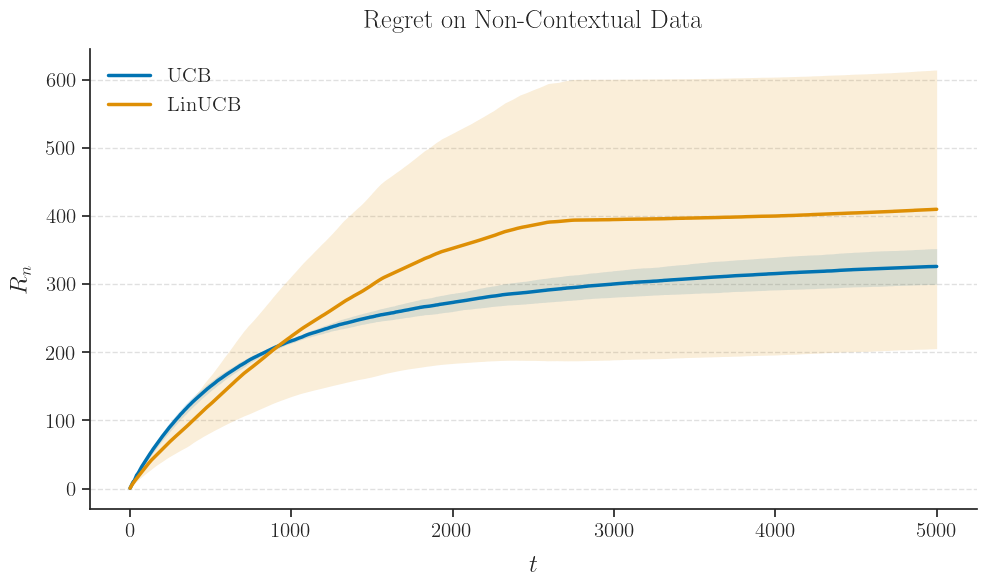

Contextual Synthetic


100%|██████████| 20/20 [00:14<00:00,  1.40it/s]


saved as exp_context.pdf


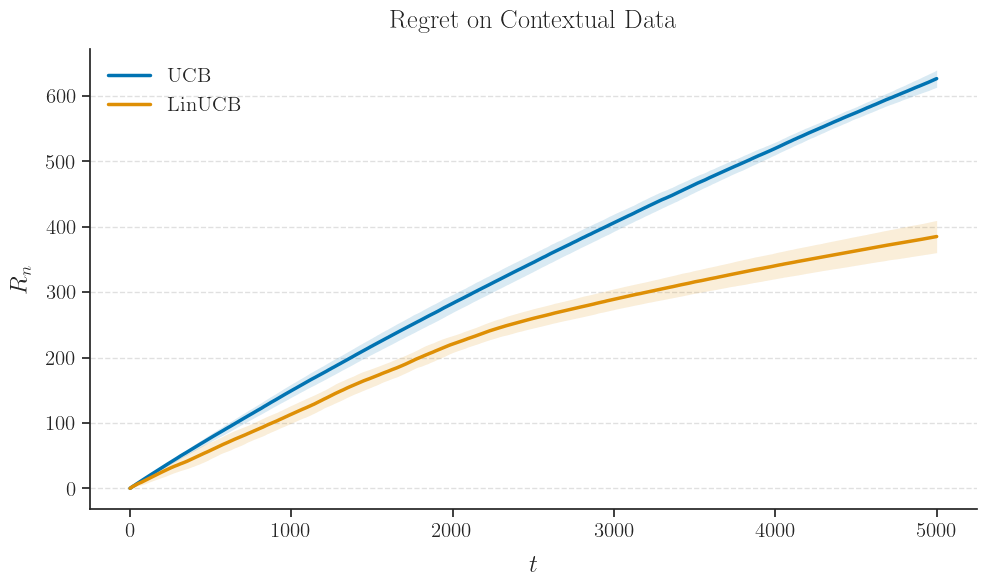

saved as exp_cpombined.pdf


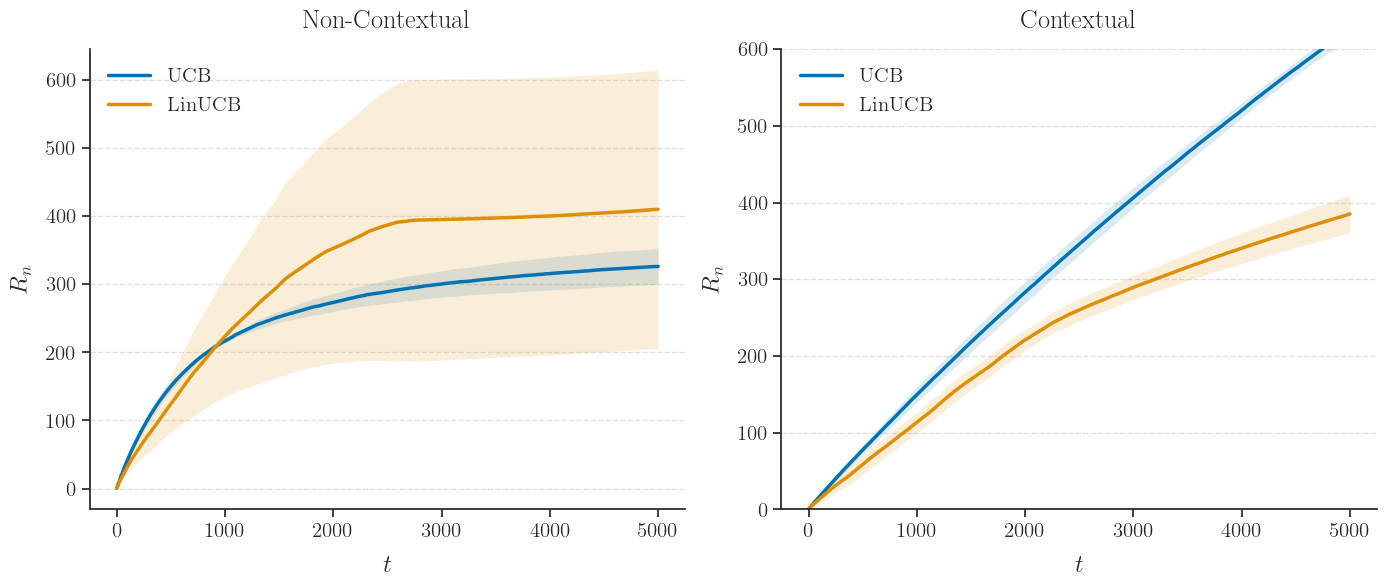

MovieLens Offline Replay


100%|██████████| 20/20 [04:44<00:00, 14.24s/it]


saved as exp_movielens.pdf


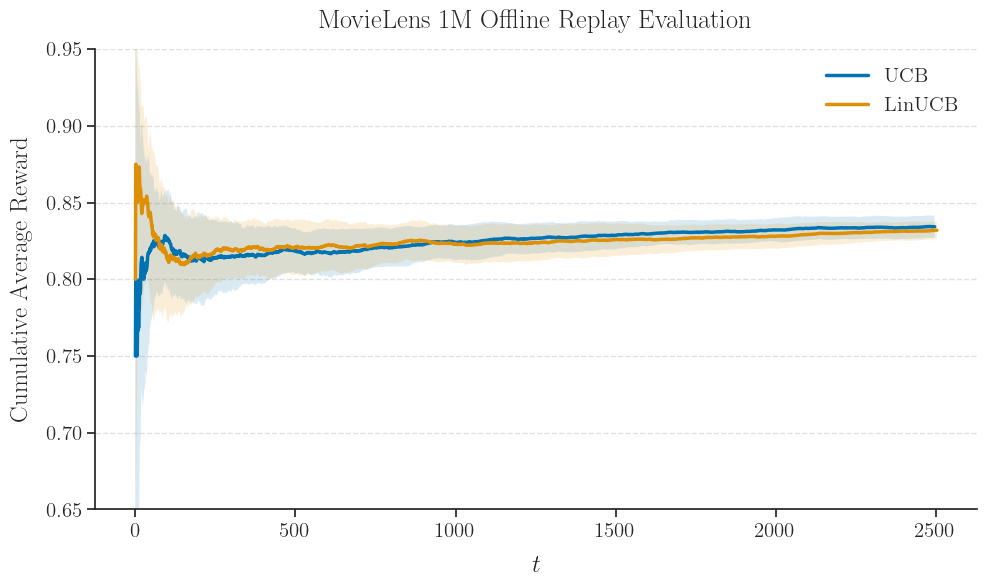

In [44]:
df_ml, feature_cols, K_ARMS = load_and_prep_movielens()
d_context = len(feature_cols)

SEEDS = 20
ROUNDS = 5000
K_ARMS = 20
D_DIM = 30
DELTA = 0.01

# Non-Contextual Synthetic Experiment
print("Non-Contextual Synthetic")
results_exp1 = {'UCB': [], 'LinUCB': []}
for s in tqdm(range(SEEDS)):
    np.random.seed(s)
    ucb = UCB(K_ARMS, DELTA)
    linucb = LinUCB(K_ARMS, D_DIM) # LinUCB random dummy context
    print("linUCB shape V: ", linucb.V.shape, linucb.V_inv.shape) 
    
    results_exp1['UCB'].append(run_synthetic_experiment(ucb, ROUNDS, D_DIM, K_ARMS, is_contextual=False))
    results_exp1['LinUCB'].append(run_synthetic_experiment(linucb, ROUNDS, D_DIM, K_ARMS, is_contextual=False))

plot_results(results_exp1, "Regret on Non-Contextual Data", "$R_n$", filename= 'exp_no_context.pdf')

# Contextual Synthetic Experiment
print("Contextual Synthetic")
results_exp2 = {'UCB': [], 'LinUCB': []}
for s in tqdm(range(SEEDS)):
    np.random.seed(s)
    ucb =UCB(K_ARMS, DELTA)
    linucb = LinUCB(K_ARMS, D_DIM)
    
    results_exp2['UCB'].append(run_synthetic_experiment(ucb, ROUNDS, D_DIM, K_ARMS, is_contextual=True))
    results_exp2['LinUCB'].append(run_synthetic_experiment(linucb, ROUNDS, D_DIM, K_ARMS, is_contextual=True))

plot_results(results_exp2, "Regret on Contextual Data", "$R_n$", filename= 'exp_context.pdf')

plot_combined_results(
    dict_left=results_exp1, 
    dict_right=results_exp2, 
    title_left="Non-Contextual", 
    title_right="Contextual", 
    ylabel=r"$R_n$", 
    main_title="Comparison of UCB and LinUCB on non-contextual and contextual synthetic data",
    filename= 'exp_cpombined.pdf',
    ylim=(0.0, 600)
)

# Offline Replay on MovieLens
print("MovieLens Offline Replay")
results_exp3 = {'UCB': [], 'LinUCB': []}
for s in tqdm(range(SEEDS)):
    np.random.seed(s)
    ucb = UCB(K_ARMS, DELTA)
    linucb = LinUCB(K_ARMS, d_context)
    
    results_exp3['UCB'].append(run_offline_replay(ucb, df_ml, feature_cols))
    results_exp3['LinUCB'].append(run_offline_replay(linucb, df_ml, feature_cols))

plot_results(results_exp3, "MovieLens 1M Offline Replay Evaluation", "Cumulative Average Reward", filename= 'exp_movielens.pdf', ylim=(0.65, 0.95))

<>:26: SyntaxWarning: invalid escape sequence '\g'
<>:26: SyntaxWarning: invalid escape sequence '\g'
/var/folders/lx/yjmbmcz505xgn_k0sg7_p80c0000gn/T/ipykernel_56024/3563663188.py:26: SyntaxWarning: invalid escape sequence '\g'
  ax.set_ylabel('Share with Rating $\ge 4$', fontsize=18, labelpad=10)


Plot saved as fig_3_movie_baselines.pdf


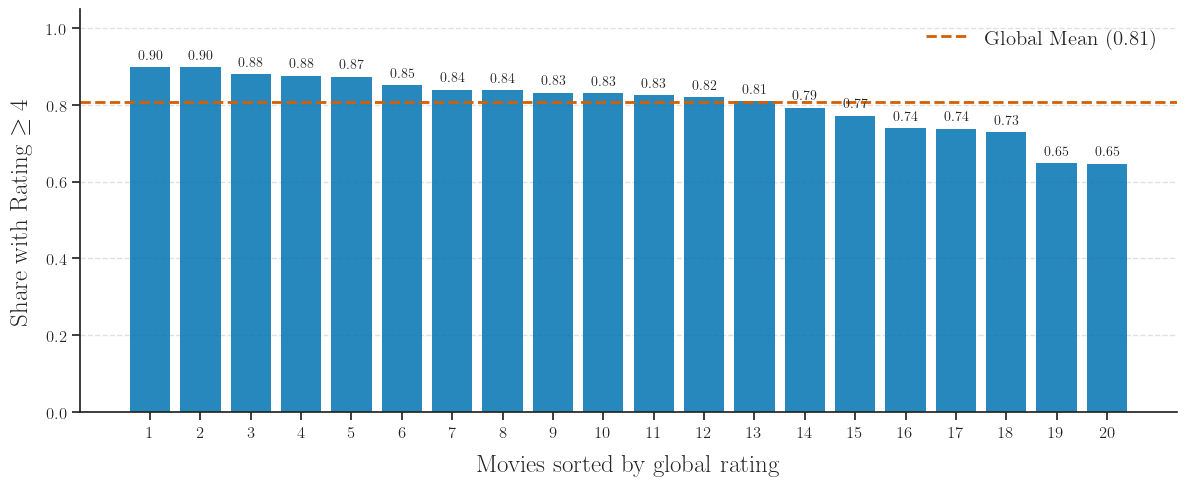

In [46]:
def plot_movie_baselines(df, top_k=20, filename=None):
    movie_stats = df.groupby('Arm')['Reward'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
    
    sns.set_theme(style="ticks")

    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    })

    fig, ax = plt.subplots(figsize=(12, 5))
    
    primary_color = sns.color_palette("colorblind")[0]
    mean_color = sns.color_palette("colorblind")[3] 
    
    bars = ax.bar(range(len(movie_stats)), movie_stats['mean'], alpha=0.85, color=primary_color, linewidth=0)
    
    ax.set_xlabel(r'Movies sorted by global rating', fontsize=18, labelpad=10)
    ax.set_ylabel('Share with Rating $\ge 4$', fontsize=18, labelpad=10)
    
    ax.set_xticks(range(len(movie_stats)))
    ax.set_xticklabels([f"{i+1}" for i in range(len(movie_stats))], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_ylim(0, 1.05)
    
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.015, f'{yval:.2f}', 
                ha='center', va='bottom', fontsize=10)
        
    global_mean = df['Reward'].mean()
    ax.axhline(global_mean, color=mean_color, linestyle='--', linewidth=2, label=f'Global Mean ({global_mean:.2f})')
    
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    sns.despine()
    ax.legend(loc='upper right', fontsize=15, frameon=False)
    plt.tight_layout()
    
    if filename:
        plt.savefig(filename, bbox_inches='tight', transparent=True, dpi=300)
        print(f"Plot saved as {filename}")
        
    plt.show()

plot_movie_baselines(df_ml, top_k=K_ARMS, filename="fig_3_movie_baselines.pdf")